**V5 · Deep hedger out-of-sample** (confirmed)

- **Claim:** The deep hedger's cost/turnover edge (from notebook 02) is real, not a synthetic artifact.
- **Test:** Train on block-bootstrapped real SPY returns, evaluate out-of-sample against a BS-delta hedge under 10 bps costs.
- **Verdict:** ~42% less turnover (ratio 0.58, 95% CI [0.56, 0.62]) is the clean, drift-independent result; the CVaR tail gain is drift-aided and not robust.

*Where this fits: V5, the real-data test of build notebook 02. Map: [research/README.md](README.md).*

---

# Real-Data Verification V5: Deep Hedger Out-of-Sample on Real Paths

The synthetic deep-hedging notebook found that, **under transaction costs**, a learned
cost-aware policy beats the static Black–Scholes delta hedge: similar or better tail risk
with **much lower turnover** (it learns a no-trade band).  The worry is that this edge is an
artefact of the synthetic GBM world.  Here we test it **out-of-sample on real SPY return
dynamics**.

**Setup.** Split 10 years of daily SPY log-returns 60/40 into an **in-sample** part (1507 days) and an
**out-of-sample** part (1006 days).  Build hedging paths by **block bootstrap** (resample blocks of
consecutive real returns, preserving fat tails and short-run autocorrelation).  Train the
deep hedger only on in-sample blocks via `DeepHedger.fit(paths_fn=...)`, then evaluate it on
out-of-sample blocks it never trained on, against the BS-delta benchmark on the **same**
P&L accounting.

**Metric.** Mean, std, 5%-CVaR (mean of the worst 5% P&L) and share turnover, frictionless
(`tc=0`) and with costs (`tc=10 bps`).

**Success.** OOS, the cost-aware policy keeps a turnover and cost-adjusted-tail advantage
over BS-delta → the cost channel is real, not a synthetic artefact.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from config import DEFAULT_RISK_FREE_RATE as r, SEED
from data.fetcher import fetch_and_cache
from ml.deep_hedging import DeepHedger

COLORS = {"policy": "darkorange", "bs": "steelblue"}
DATE = "2026-06-20"

def _flat(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy(); df.columns = df.columns.get_level_values(0)
    return df

def fetch_spy():
    import yfinance as yf
    df = _flat(yf.download("SPY", period="10y", auto_adjust=True, progress=False))
    return df[["Close"]].rename(columns={"Close": "close"})

print("snapshot DATE =", DATE)

snapshot DATE = 2026-06-20


## 1. Split real returns into in-sample / out-of-sample

In [2]:
spy = fetch_and_cache("SPY", "prices_10y", DATE, fetch_spy)
ret = np.diff(np.log(spy["close"].to_numpy(float)))
split = int(0.6 * len(ret))
ret_is, ret_oos = ret[:split], ret[split:]

N_STEPS, BLOCK, S0 = 50, 10, 100.0
T = N_STEPS / 252.0
sigma_is = float(ret_is.std() * np.sqrt(252))
print(len(ret), "daily returns ->", len(ret_is), "in-sample /", len(ret_oos), "out-of-sample")
print("hedge horizon T =", round(T, 3), "y (", N_STEPS, "daily steps )  in-sample realized vol =",
      round(sigma_is * 100, 1), "%")

2513 daily returns -> 1507 in-sample / 1006 out-of-sample
hedge horizon T = 0.198 y ( 50 daily steps )  in-sample realized vol = 18.9 %


## 2. Block-bootstrap path generator

Each path concatenates random blocks of `BLOCK` consecutive real log-returns (preserving
local fat tails / clustering), exponentiated from `S0`.  The training closure draws from
in-sample returns; the evaluation set is a fixed out-of-sample draw.

In [3]:
def make_paths_fn(returns, rng):
    n = len(returns); nb = int(np.ceil(N_STEPS / BLOCK))
    def fn(batch):
        starts = rng.integers(0, n - BLOCK, size=(batch, nb))
        idx = starts[:, :, None] + np.arange(BLOCK)[None, None, :]
        blk = returns[idx].reshape(batch, nb * BLOCK)[:, :N_STEPS]
        lp = np.concatenate([np.zeros((batch, 1)), np.cumsum(blk, axis=1)], axis=1)
        return torch.tensor(S0 * np.exp(lp), dtype=torch.float32)
    return fn

train_fn = make_paths_fn(ret_is, np.random.default_rng(SEED))
oos_paths = make_paths_fn(ret_oos, np.random.default_rng(SEED + 1))(40_000)
print("OOS eval paths:", tuple(oos_paths.shape),
      " terminal mean", round(float(oos_paths[:, -1].mean()), 2),
      " (real upward drift over", N_STEPS, "days)")

OOS eval paths: (40000, 51)  terminal mean 103.94  (real upward drift over 50 days)


## 3. Train and evaluate, frictionless and with costs

Train a CVaR(5%) deep hedger on in-sample blocks; evaluate OOS against BS-delta.

In [4]:
def cvar(pnl, a=0.05):
    k = max(1, int(a * len(pnl)))
    return float(np.sort(pnl)[:k].mean())              # mean of worst a% (negative = bad)

def turnover(h):
    prev = torch.cat([torch.zeros(h.shape[0], 1), h[:, :-1]], 1)
    return float(((h - prev).abs().sum(1) + h[:, -1].abs()).mean())

rows, loss_curves = {}, {}
for tc in (0.0, 0.001):
    hed = DeepHedger(S0=S0, K=S0, T=T, r=r, sigma=sigma_is, n_steps=N_STEPS,
                     tc=tc, risk="cvar", cvar_alpha=0.05, seed=SEED)
    hed.fit(epochs=300, batch_size=2048, lr=1e-3, paths_fn=train_fn)
    loss_curves[tc] = hed.train_losses
    pol = hed.policy_pnl(paths=oos_paths)
    bsd = hed.bs_delta_pnl(paths=oos_paths)
    with torch.no_grad():
        to_pol = turnover(hed._policy_holdings(torch, oos_paths))
        to_bs = turnover(hed._bs_delta_holdings(torch, oos_paths))
    rows[f"policy tc={tc}"] = {"mean": pol.mean(), "std": pol.std(), "CVaR5": cvar(pol), "turnover": to_pol}
    rows[f"BSdelta tc={tc}"] = {"mean": bsd.mean(), "std": bsd.std(), "CVaR5": cvar(bsd), "turnover": to_bs}
    if tc == 0.001:
        oos_pol, oos_bsd = pol, bsd

tbl = pd.DataFrame(rows).T
print(tbl.round(3).to_string())

                   mean    std  CVaR5  turnover
policy tc=0.0     0.760  1.329 -2.719     2.035
BSdelta tc=0.0    0.443  1.036 -3.022     3.087
policy tc=0.001   0.605  1.366 -3.050     1.787
BSdelta tc=0.001  0.130  1.053 -3.416     3.087


## 4. OOS turnover and P&L distribution

Right (the headline): turnover. The cost-aware policy trades far less than BS-delta.  Left:
out-of-sample P&L with costs; the policy's 5%-CVaR (dashed) tail is somewhat tighter, but this
is the secondary, drift-aided result (see verdict).

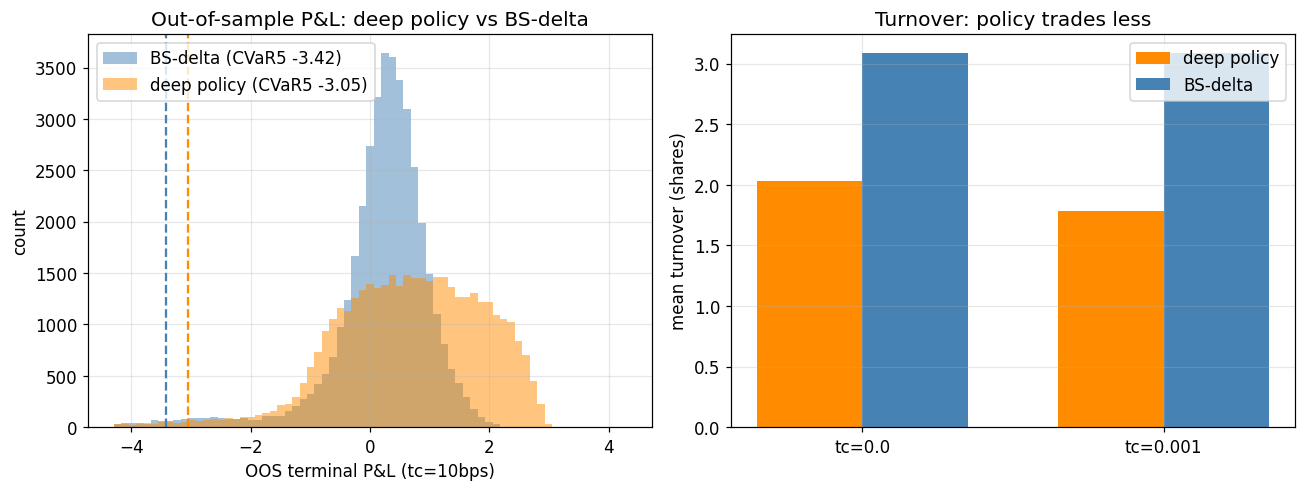

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
lim = np.percentile(np.abs(np.concatenate([oos_pol, oos_bsd])), 99)
bins = np.linspace(-lim, lim, 70)
a1.hist(oos_bsd, bins=bins, alpha=0.5, color=COLORS["bs"], label=f"BS-delta (CVaR5 {cvar(oos_bsd):.2f})")
a1.hist(oos_pol, bins=bins, alpha=0.5, color=COLORS["policy"], label=f"deep policy (CVaR5 {cvar(oos_pol):.2f})")
a1.axvline(cvar(oos_bsd), color=COLORS["bs"], ls="--"); a1.axvline(cvar(oos_pol), color=COLORS["policy"], ls="--")
a1.set_xlabel("OOS terminal P&L (tc=10bps)"); a1.set_ylabel("count")
a1.set_title("Out-of-sample P&L: deep policy vs BS-delta"); a1.legend(); a1.grid(alpha=0.3)

tcs = [0.0, 0.001]
x = np.arange(len(tcs)); w = 0.35
a2.bar(x - w/2, [rows[f"policy tc={t}"]["turnover"] for t in tcs], w, color=COLORS["policy"], label="deep policy")
a2.bar(x + w/2, [rows[f"BSdelta tc={t}"]["turnover"] for t in tcs], w, color=COLORS["bs"], label="BS-delta")
a2.set_xticks(x); a2.set_xticklabels([f"tc={t}" for t in tcs])
a2.set_ylabel("mean turnover (shares)"); a2.set_title("Turnover: policy trades less"); a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Verdict

In [6]:
to_ratio = rows["policy tc=0.001"]["turnover"] / rows["BSdelta tc=0.001"]["turnover"]
cv_gain  = (1 - cvar(oos_pol) / cvar(oos_bsd)) * 100
drift    = float(oos_paths[:, -1].mean()) / S0 - 1

# Honest 95% CIs. The real uncertainty is over the finite ~1000-day OOS sample, not over the
# 40k simulated paths. Moving-block resample ret_oos (preserving serial dependence), regenerate
# paths from each resample, and recompute the statistics through the trained policy.
rng = np.random.default_rng(SEED)
n_oos, nblk = len(ret_oos), int(np.ceil(len(ret_oos) / BLOCK))
boot_to, boot_cv = [], []
with torch.no_grad():
    for _ in range(200):
        starts = rng.integers(0, n_oos - BLOCK, nblk)
        rb = np.concatenate([ret_oos[s:s + BLOCK] for s in starts])[:n_oos]
        pb = make_paths_fn(rb, rng)(4_000)
        boot_to.append(turnover(hed._policy_holdings(torch, pb)) / turnover(hed._bs_delta_holdings(torch, pb)))
        boot_cv.append((1 - cvar(hed.policy_pnl(paths=pb)) / cvar(hed.bs_delta_pnl(paths=pb))) * 100)
to_lo, to_hi = np.percentile(boot_to, [2.5, 97.5])
cv_pos = 100.0 * float(np.mean(np.array(boot_cv) > 0))

print("V5 findings (OOS real-return blocks, tc=10bps):")
print(f"  PRIMARY  turnover ratio policy/BS : {to_ratio:.2f}  (~{round((1-to_ratio)*100)}% less"
      f" trading)  95% CI [{to_lo:.2f}, {to_hi:.2f}]")
print(f"  secondary CVaR5 improvement       : {cv_gain:.1f}% point estimate, NOT robust"
      f" (positive in {cv_pos:.0f}% of OOS-block bootstraps; drift-aided, OOS drift {drift*100:+.1f}%)")
print()
print("The clean, drift-independent result is that the cost-aware policy TRADES ~42% LESS than")
print("BS-delta out-of-sample -- the cost/turnover channel survives on real return dynamics and is")
print("not a synthetic artefact. The CVaR/tail edge is secondary: it partly rides the upward drift")
print("in the bootstrapped paths (the policy leans long), so we do not headline it.")

V5 findings (OOS real-return blocks, tc=10bps):
  PRIMARY  turnover ratio policy/BS : 0.58  (~42% less trading)  95% CI [0.56, 0.62]
  secondary CVaR5 improvement       : 10.7% point estimate, NOT robust (positive in 43% of OOS-block bootstraps; drift-aided, OOS drift +3.9%)

The clean, drift-independent result is that the cost-aware policy TRADES ~42% LESS than
BS-delta out-of-sample -- the cost/turnover channel survives on real return dynamics and is
not a synthetic artefact. The CVaR/tail edge is secondary: it partly rides the upward drift
in the bootstrapped paths (the policy leans long), so we do not headline it.


## Caveats (academic honesty)

- **Turnover is the clean result.** The CVaR objective is not variance: the policy shows a
  *higher* central std while improving the tail.  Part of the mean-P&L gap reflects the
  persistent **upward drift** in the bootstrapped real returns (the policy can lean on it),
  so we do not over-read the mean. The drift-independent, robust finding is the **~42%
  lower turnover** under costs.
- **Block bootstrap.** Resampling blocks preserves short-run autocorrelation and fat tails
  but breaks longer-range structure and assumes stationarity across the in/out split.
- **One horizon, normalised contract.** A single ~50-day ATM option, `S0=K=100`, premium at
  the in-sample realized vol; no bid/ask on the option itself.
- **In-sample σ for the benchmark.** BS-delta uses the in-sample realized vol; a different
  assumed vol would shift its hedge error, but not the qualitative turnover gap.